# 4. Análisis Espacial y Multivariado de Riesgos
Este notebook integra los datos de factores de riesgo, específicamente la **calidad del agua (IRCA)** y la **prevalencia del consumo de tabaco**, visualizándolos espacialmente sobre el mapa de Colombia y explorando su relación con la mortalidad.

In [19]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

### 1. Carga del Mapa (Shapefile) de Departamentos

In [20]:
ruta_shape = "Datos/Mapa/MGN_ANM_DPTOS.shp"
try:
    gdf_dptos = gpd.read_file(ruta_shape)
    # El shapefile de Colombia suele tener la columna DPTO_CCDGO como el código de departamento
    col_codigo = 'DPTO_CCDGO' if 'DPTO_CCDGO' in gdf_dptos.columns else gdf_dptos.columns[0]
    
    # Aseguramos que el código de departamento sea numérico para poder cruzar los datos
    gdf_dptos['cod_dpto'] = pd.to_numeric(gdf_dptos[col_codigo], errors='coerce')
    print("Shapefile cargado exitosamente. Total departamentos:", len(gdf_dptos))
except Exception as e:
    print("Error cargando shapefile:", e)

Shapefile cargado exitosamente. Total departamentos: 33


### 2. Carga y Procesamiento de Bases de Riesgo (IRCA y Tabaco)
Extraemos la información directamente desde nuestros archivos CSV y Excel. Para el caso del Índice de Riesgo de la Calidad del Agua (IRCA), al contar con un histórico anual, agregaremos la información obteniendo un promedio global por departamento para la visualización agregada.

In [21]:
# A. Calidad del Agua (IRCA)
df_irca = pd.read_csv("Datos/Extra/IRCA_DPTO.csv")
df_irca['cod_dpto'] = pd.to_numeric(df_irca['DepartamentoCodigo'], errors='coerce')
df_irca['IRCA'] = pd.to_numeric(df_irca['IRCA'], errors='coerce')
df_irca_promedio = df_irca.groupby('cod_dpto')['IRCA'].mean().reset_index()
print("Datos IRCA cargados y promediados.")

# B. Prevalencia de Tabaco
df_tabaco = pd.read_excel("Datos/Extra/Tabaco.xlsx")
df_tabaco['cod_dpto'] = pd.to_numeric(df_tabaco['Código DANE'], errors='coerce')
df_tabaco = df_tabaco[['cod_dpto', 'Prevalencia Vida (%)']].rename(columns={'Prevalencia Vida (%)': 'prevalencia_tabaco'})
print("Datos de Tabaco cargados.")

Datos IRCA cargados y promediados.
Datos de Tabaco cargados.


### 3. Fusión de Variables Espaciales y Creación de Choropleth Maps
Unimos el dataframe geográfico con nuestros dataframes de riesgo.

In [22]:
# Merge geográfico (Left join para no perder fragmentos del mapa si nos falta data de algún departamento)
gdf_mapa = gdf_dptos.merge(df_irca_promedio, on='cod_dpto', how='left')
gdf_mapa = gdf_mapa.merge(df_tabaco, on='cod_dpto', how='left')

gdf_mapa[['cod_dpto', 'IRCA', 'prevalencia_tabaco']].head()

,cod_dpto,IRCA,prevalencia_tabaco
0,18,16.270588,23.4
1,19,15.388889,31.8
2,86,38.127778,27.2
3,76,13.705556,31.0
4,94,34.786667,33.8


C:\Users\andre\AppData\Local\Temp\ipykernel_6848\3785426982.py:28: UserWarning: Glyph 137 (\x89) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 137 (\x89) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


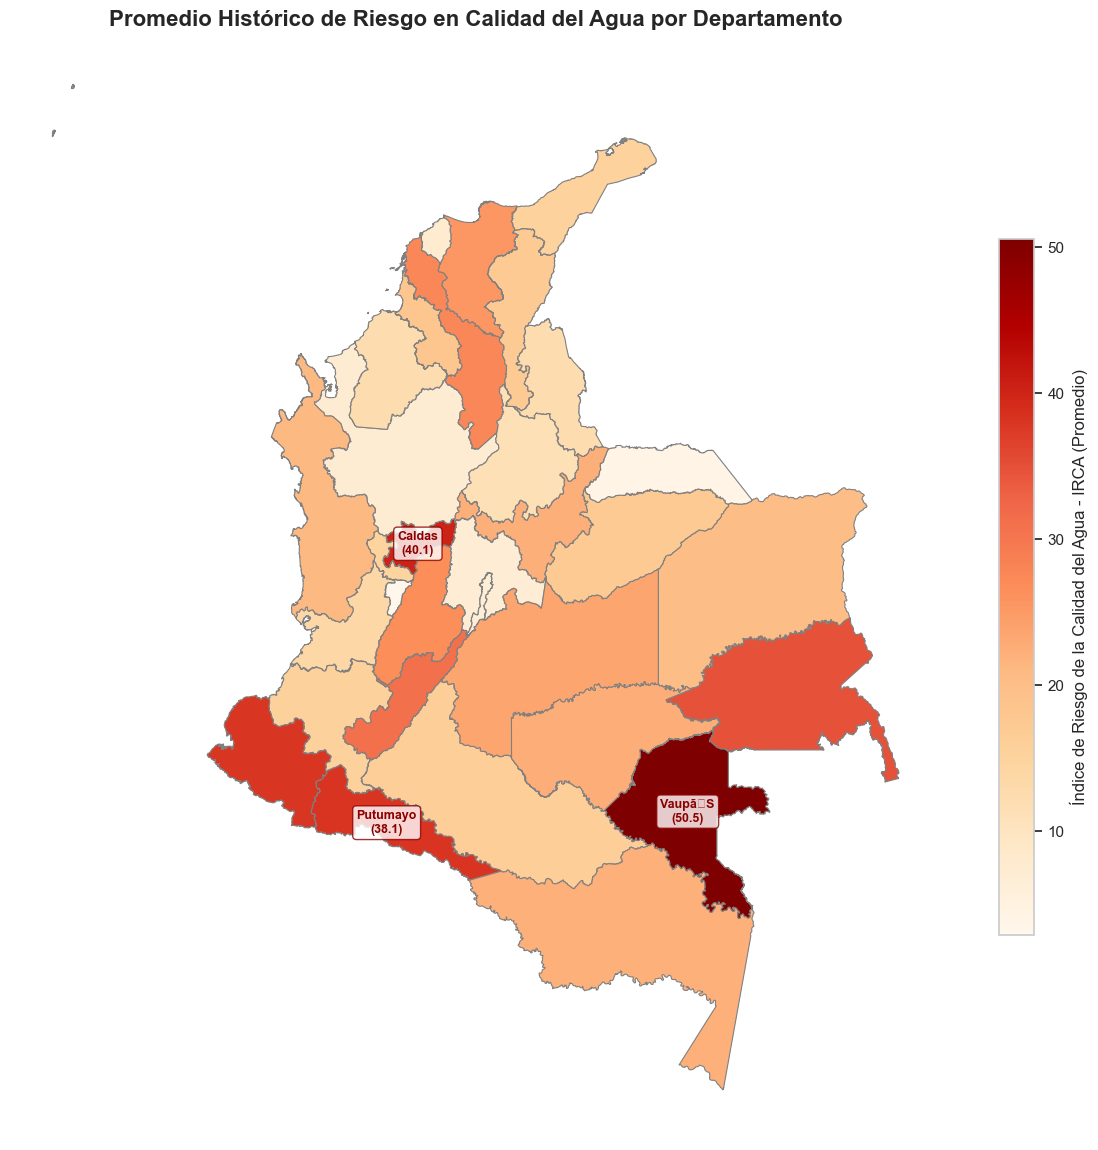

In [ ]:
# ---- MAPA 1: IRCA ----
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
gdf_mapa.plot(column='IRCA', cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0.5', 
              legend=True, missing_kwds={'color': 'whitesmoke', 'hatch': '///'},
              legend_kwds={'label': "Índice de Riesgo de la Calidad del Agua - IRCA (Promedio)", 'shrink': 0.6})

ax.set_title('Promedio Histórico de Riesgo en Calidad del Agua por Departamento', fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax.set_axis_off()

# Intentar buscar el nombre de la columna que podría ser el nombre del departamento
# En shapefiles DANE suele ser DPTO_CNMBR o DPNOM
col_nombre = 'DPTO_CNMBR' if 'DPTO_CNMBR' in gdf_mapa.columns else gdf_mapa.columns[1]

top_3_irca = gdf_mapa.nlargest(3, 'IRCA')

for idx, row in top_3_irca.iterrows():
    if row.geometry is not None:
        # Calcular el centroide para colocar el texto
        centroid = row.geometry.centroid
        nombre_dpto = str(row[col_nombre]).title()
        ax.annotate(f"{nombre_dpto}\n({row['IRCA']:.1f})", 
                    xy=(centroid.x, centroid.y),
                    xytext=(0,0), textcoords="offset points",
                    fontsize=9, weight='bold', color='darkred',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", alpha=0.8),
                    ha='center', va='center')

# ----- TEXTO DE ESCALA IRCA -----
texto_escala = (
    "Escala Oficial IRCA (0 - 100):\n"
    "0 - 5 : Sin Riesgo\n"
    "5 - 14: Bajo\n"
    "14 - 35: Medio\n"
    "35 - 80: Alto\n"
    "80 - 100: Inviable"
)
ax.text(0.02, 0.15, texto_escala, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

**Interpretación (IRCA):** 
Este mapa resalta en tonos más oscuros los departamentos con los promedios históricos más altos (peor calidad) en el Índice de Riesgo de Calidad del Agua. Históricamente, las zonas apartadas o con menor infraestructura de saneamiento básico tienden a presentar niveles altos de IRCA. Los 3 departamentos anotados son aquellos donde el consumo de agua supone un mayor riesgo toxicológico y bacteriológico constante en el periodo estudiado, siendo esto un factor crítico relacionado con la alta incidencia poblacional a patógenos gástricos como el *Helicobacter pylori*.

C:\Users\andre\AppData\Local\Temp\ipykernel_6848\2226136807.py:25: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


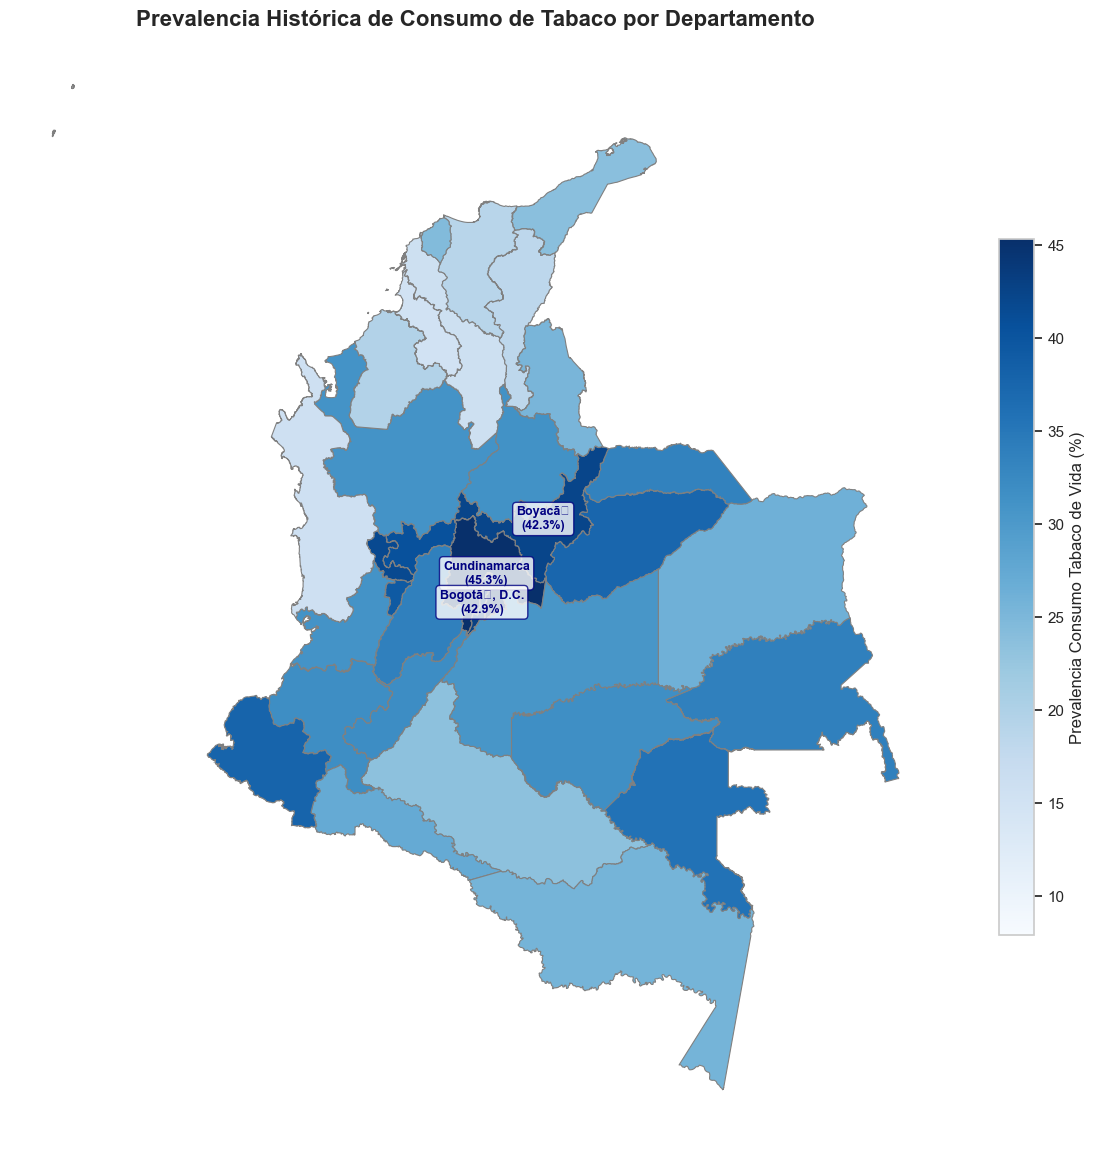

In [24]:
# ---- MAPA 2: PREVALENCIA TABACO ----
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
gdf_mapa.plot(column='prevalencia_tabaco', cmap='Blues', linewidth=0.8, ax=ax, edgecolor='0.5', 
              legend=True, missing_kwds={'color': 'whitesmoke', 'hatch': '///'},
              legend_kwds={'label': "Prevalencia Consumo Tabaco de Vida (%)", 'shrink': 0.6})

ax.set_title('Prevalencia Histórica de Consumo de Tabaco por Departamento', fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax.set_axis_off()

# Encontrar los 3 departamentos con mayor consumo para anotar
col_nombre = 'DPTO_CNMBR' if 'DPTO_CNMBR' in gdf_mapa.columns else gdf_mapa.columns[1]
top_3_tabaco = gdf_mapa.nlargest(3, 'prevalencia_tabaco')

for idx, row in top_3_tabaco.iterrows():
    if row.geometry is not None:
        centroid = row.geometry.centroid
        nombre_dpto = str(row[col_nombre]).title()
        ax.annotate(f"{nombre_dpto}\n({row['prevalencia_tabaco']:.1f}%)", 
                    xy=(centroid.x, centroid.y),
                    xytext=(0,0), textcoords="offset points",
                    fontsize=9, weight='bold', color='navy',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="navy", alpha=0.8),
                    ha='center', va='center')

plt.tight_layout()
plt.show()

**Interpretación (Consumo de Tabaco):** 
Este mapa evidencia, mediante los clústeres azules, las zonas de Colombia con mayor prevalencia de vida de consumo de tabaco según la encuesta. Identificar los departamentos etiquetados (con tasas porcentuales considerablemente altas para la región) es clave porque el tabaquismo es el segundo factor exógeno predisponente en el desarrollo del cáncer gástrico, debido al efecto sistémico que tienen las nitrosaminas contenidas en el humo sobre las paredes del epitelio estomacal.

### 4. Matriz de Correlación: Riesgos de Mortalidad vs Variables Analíticas
A continuación interceptamos nuestros datos de riesgo con el panel de mortalidad y tasas ajustadas generado a partir de tu script `00_build_analytical_tables.py`. Así podemos medir matemáticamente si la prevalencia la mala calidad del agua influye directamente en las tasas de mortalidad.

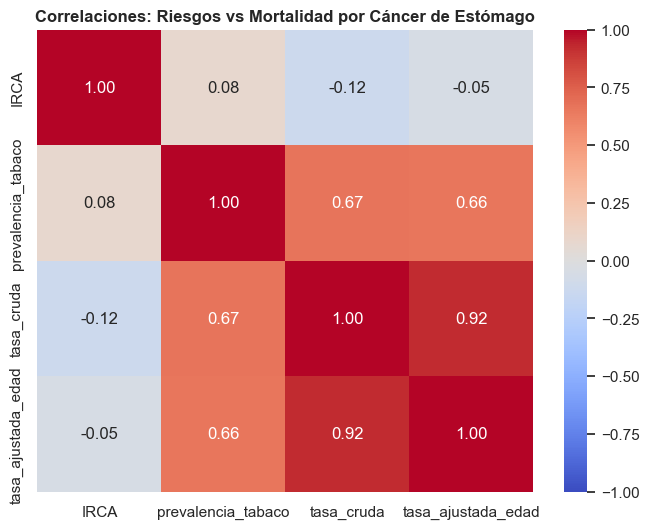

In [25]:
# Integramos la base maestra originada en las tablas analíticas si existe
ruta_panel = "proyecto/data/analytical/panel_dpto_año.parquet"

if os.path.exists(ruta_panel):
    df_panel = pd.read_parquet(ruta_panel)
    # Averiguar las tasas por departamento colapsando la variable año
    df_panel_promedio = df_panel.groupby('cod_dpto')[['tasa_cruda', 'tasa_ajustada_edad']].mean().reset_index()
    
    # Join Riesgos vs Tasas
    df_corr = df_irca_promedio.merge(df_tabaco, on='cod_dpto', how='inner').merge(df_panel_promedio, on='cod_dpto', how='inner')
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_corr[['IRCA', 'prevalencia_tabaco', 'tasa_cruda', 'tasa_ajustada_edad']].corr(), 
                annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
    plt.title("Correlaciones: Riesgos vs Mortalidad por Cáncer de Estómago", fontdict={'fontweight': 'bold'})
    plt.show()
else:
    print("El archivo panel_dpto_año.parquet aún no ha sido generado. Corre primero el script 00_build_analytical_tables.py para generarlo y poder visualizar la matriz de correlación.")

### 5. Carga de Enfermedad Geográfica: Muertes Acumuladas vs Tasa Ajustada por Edad
Para un análisis epidemiológico completo, es fundamental entender que **la cantidad de muertes** (carga absoluta) no es lo mismo que **el riesgo de muerte** (Tasa Ajustada por Edad). 
- Las muertes absolutas tienden a concentrarse en los centros poblados más grandes (Bogotá, Antioquia, Valle).
- Las **tasas ajustadas** revelan el riesgo real en la población, aislando el impacto de tener poblaciones más envejecidas o numerosas en ciertas regiones.

C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\geopandas\plotting.py:950: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  ax.figure.canvas.draw_idle()
C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


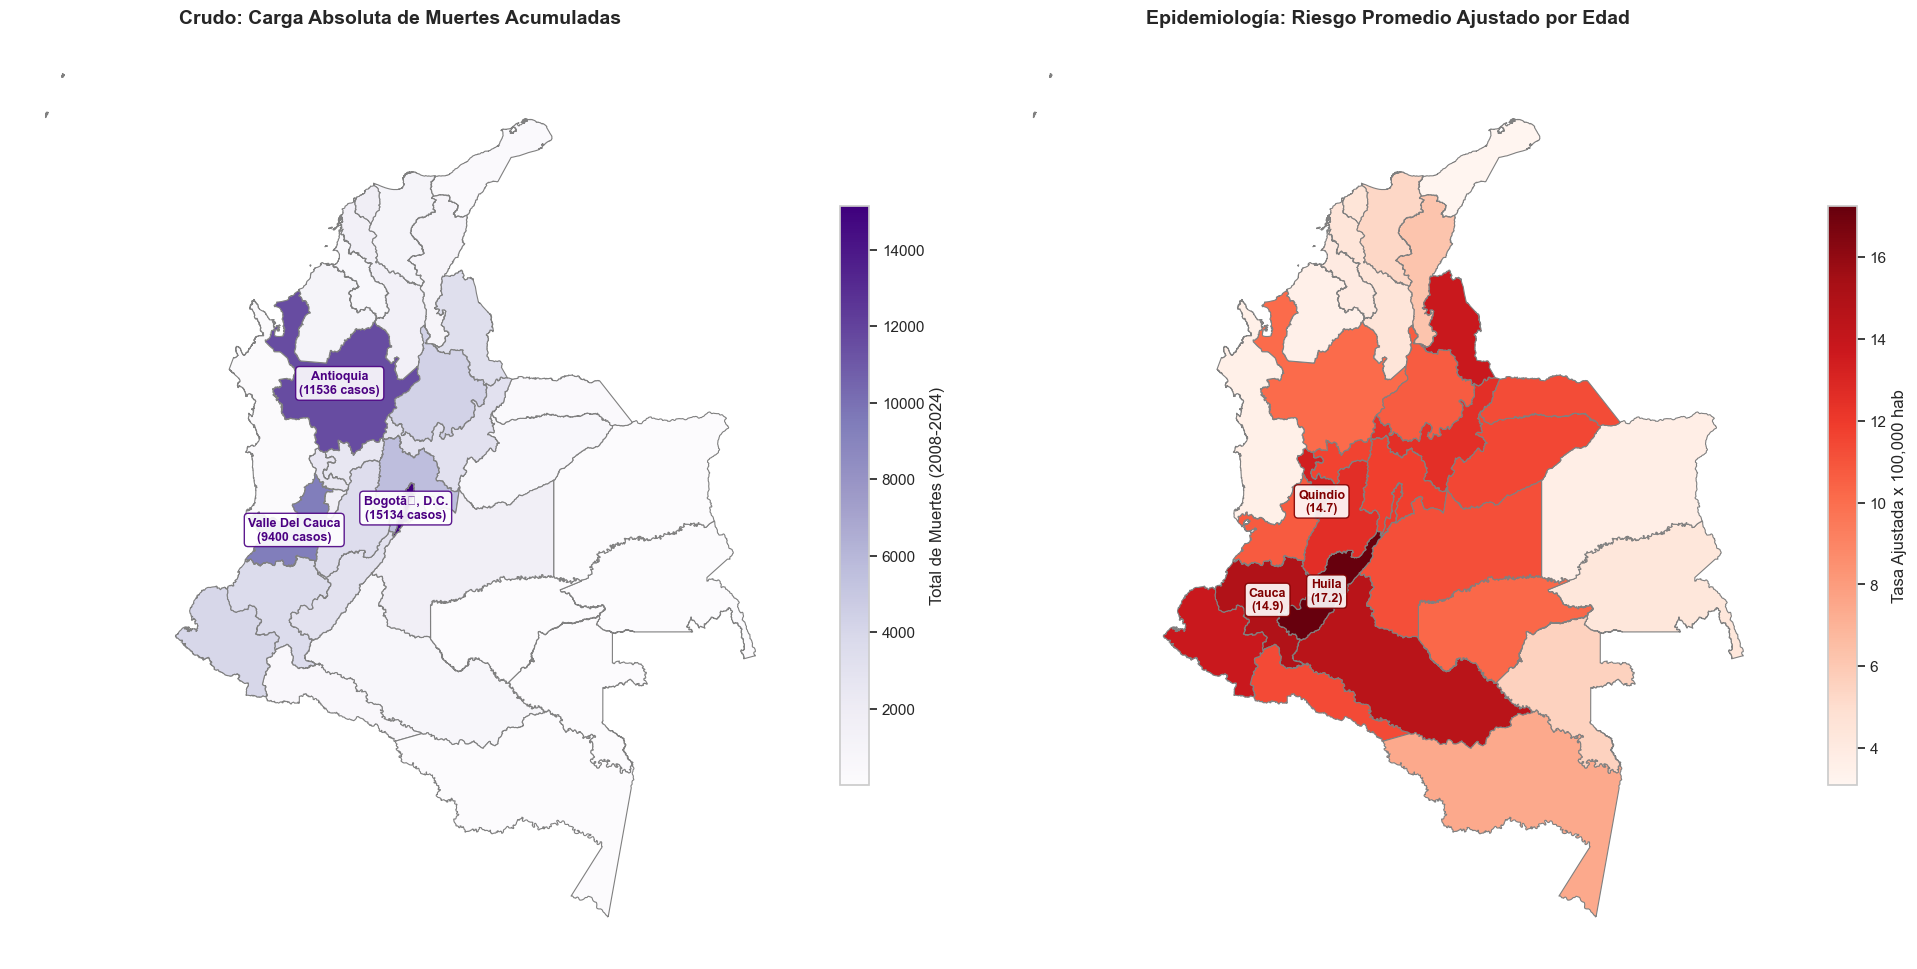

In [ ]:
if os.path.exists(ruta_panel):
    # Calcular muertes acumuladas y promedios de tasas
    df_panel_total = df_panel.groupby('cod_dpto').agg(
        muertes_acumuladas=('muertes_total', 'sum'),
        tasa_ajustada_promedio=('tasa_ajustada_edad', 'mean')
    ).reset_index()
    
    # Merge con el mapa
    gdf_mapa_mortalidad = gdf_dptos.merge(df_panel_total, on='cod_dpto', how='left')
    
    # Crear figura
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    
    # --- MAPA A: Muertes Acumuladas
    gdf_mapa_mortalidad.plot(column='muertes_acumuladas', cmap='Purples', linewidth=0.8, ax=ax, edgecolor='0.5', 
                        legend=True, missing_kwds={'color': 'whitesmoke', 'hatch': '///'},
                        legend_kwds={'label': "Total de Muertes (2008-2024)", 'shrink': 0.6})
    ax.set_title('Crudo: Carga Absoluta de Muertes Acumuladas', fontdict={'fontsize': 16, 'fontweight': 'bold'})
    ax.set_axis_off()
    
    # Anotar Top 3 Absolutos
    top_3_abs = gdf_mapa_mortalidad.nlargest(3, 'muertes_acumuladas')
    for idx, row in top_3_abs.iterrows():
        if row.geometry is not None:
            centroid = row.geometry.centroid
            nombre_dpto = str(row[col_nombre]).title()
            ax.annotate(f"{nombre_dpto}\n({int(row['muertes_acumuladas'])} casos)", 
                        xy=(centroid.x, centroid.y), xytext=(0,0), textcoords="offset points",
                        fontsize=9, weight='bold', color='indigo',
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="indigo", alpha=0.9), ha='center', va='center')
                        
    plt.tight_layout()
    plt.show()

### 6. Carga de Enfermedad Geográfica: Tasa Ajustada por Edad (El riesgo poblacional real)
Si bien las métricas de carga absoluta muestran el impacto natural al que un sistema de salud se enfrenta masivamente, las **tasas ajustadas** (siguiente gráfico) revelan el riesgo verdadero aislando el impacto de poblaciones grandes. Estas resaltan los verdaderos focos de ocurrencia epidemiológica y riesgo biológico en los territorios.

In [ ]:
if os.path.exists(ruta_panel):
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    
    # --- MAPA B: Tasa Ajustada por Edad (El riesgo real)
    gdf_mapa_mortalidad.plot(column='tasa_ajustada_promedio', cmap='Reds', linewidth=0.8, ax=ax, edgecolor='0.5', 
                        legend=True, missing_kwds={'color': 'whitesmoke', 'hatch': '///'},
                        legend_kwds={'label': "Tasa Ajustada x 100,000 hab", 'shrink': 0.6})
    ax.set_title('Epidemiología: Riesgo Promedio Ajustado por Edad', fontdict={'fontsize': 16, 'fontweight': 'bold'})
    ax.set_axis_off()

    # Anotar Top 3 Tasas (Verdadero riesgo)
    top_3_tasa = gdf_mapa_mortalidad.nlargest(3, 'tasa_ajustada_promedio')
    for idx, row in top_3_tasa.iterrows():
        if row.geometry is not None:
            centroid = row.geometry.centroid
            nombre_dpto = str(row[col_nombre]).title()
            ax.annotate(f"{nombre_dpto}\n({row['tasa_ajustada_promedio']:.1f})", 
                        xy=(centroid.x, centroid.y), xytext=(0,0), textcoords="offset points",
                        fontsize=9, weight='bold', color='maroon',
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="maroon", alpha=0.9), ha='center', va='center')

    plt.tight_layout()
    plt.show()